In [2]:
!pip install opendatasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split


In [3]:
import pandas as pd

#Load Data set
import opendatasets as od

# Paste your Kaggle dataset URL here
dataset_url = 'https://www.kaggle.com/datasets/satyabrat35/amazon-food-review-dataset'
od.download(dataset_url)

# Function to parse the finefoods.txt file
def parse_finefoods_data(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        entry = {}
        for line in f:
            line = line.strip()
            if line:
                if line.startswith('product/productId:'):
                    entry['productId'] = line.split(': ')[1]
                elif line.startswith('review/userId:'):
                    entry['userId'] = line.split(': ')[1]
                elif line.startswith('review/profileName:'):
                    entry['profileName'] = line.split(': ')[1]
                elif line.startswith('review/helpfulness:'):
                    entry['helpfulness'] = line.split(': ')[1]
                elif line.startswith('review/score:'):
                    entry['Score'] = float(line.split(': ')[1])
                elif line.startswith('review/time:'):
                    entry['time'] = int(line.split(': ')[1])
                elif line.startswith('review/summary:'):
                    entry['summary'] = line.split(': ')[1]
                elif line.startswith('review/text:'):
                    entry['Text'] = line.split(': ')[1]
            else: # Blank line indicates end of an entry
                if entry:
                    data.append(entry)
                entry = {}
        if entry: # Add the last entry if file doesn't end with a blank line
            data.append(entry)
    return pd.DataFrame(data)

# File path after download
data_file_path = './amazon-food-review-dataset/finefoods.txt'
df = parse_finefoods_data(data_file_path)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nilantach
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/satyabrat35/amazon-food-review-dataset


100%|██████████| 118M/118M [00:01<00:00, 108MB/s]


In [4]:
df.head(5)

,productId,userId,profileName,helpfulness,Score,time,summary,Text
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1/1,5.0,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0/0,1.0,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1/1,4.0,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3/3,2.0,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0/0,5.0,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   productId    568454 non-null  object 
 1   userId       568454 non-null  object 
 2   profileName  568454 non-null  object 
 3   helpfulness  568454 non-null  object 
 4   Score        568454 non-null  float64
 5   time         568454 non-null  int64  
 6   summary      568454 non-null  object 
 7   Text         568454 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 34.7+ MB


In [6]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (568454, 8)


In [7]:
#check missing values
print("Checking for missing values:")
display(df.isnull().sum())

Checking for missing values:


,0
productId,0
userId,0
profileName,0
helpfulness,0
Score,0
time,0
summary,0
Text,0


In [8]:
#check duplicates
print("Checking for duplicates:")
display(df.duplicated().sum())

Checking for duplicates:


np.int64(287)

#5.2 Exploratory Data Analysis (EDA)

In [9]:
#Sentiment Labeling & count
def get_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['Score'].apply(get_sentiment)

print("Sentiment distribution:")
display(df['sentiment'].value_counts())

Sentiment distribution:


,count
sentiment,
Positive,443777
Negative,82037
Neutral,42640


In [10]:
# Keep only the columns we need
df = df[['Text', 'sentiment']]

In [11]:
# Take a sample of 50,000 to meet the project's 'Minimum Expectations'
df = df.sample(n=50000, random_state=42)

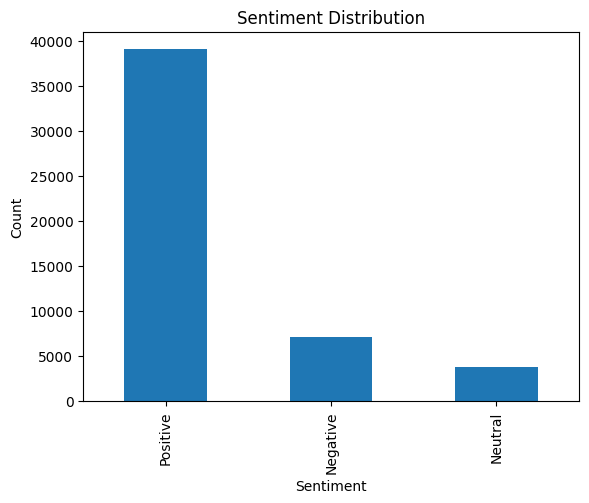

In [12]:
# Plot Sentiment Distribution
sentiment_counts = df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

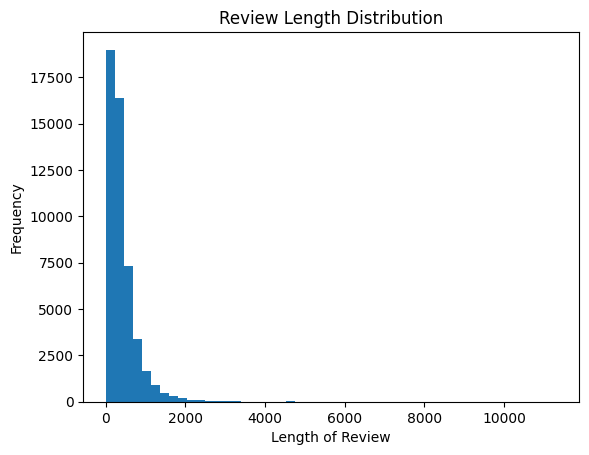

In [13]:
# Create review length column
df['review_length'] = df['Text'].fillna('').apply(len)

# Plot
plt.hist(df['review_length'], bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Length of Review')
plt.ylabel('Frequency')
plt.show()

In [14]:
from collections import Counter
import re

# Clean text
all_words = ' '.join(df['Text'].fillna('')).lower()
words = re.findall(r'\b\w+\b', all_words)

# Count words
word_counts = Counter(words)

# Top 20 words
common_words = word_counts.most_common(20)

print(common_words)

[('the', 153454), ('i', 142847), ('and', 106734), ('a', 102075), ('it', 89294), ('to', 83869), ('of', 65545), ('is', 60514), ('this', 56244), ('br', 49988), ('for', 45824), ('in', 45135), ('my', 39294), ('that', 37133), ('but', 31347), ('you', 29926), ('with', 28932), ('have', 28892), ('not', 27644), ('was', 26745)]


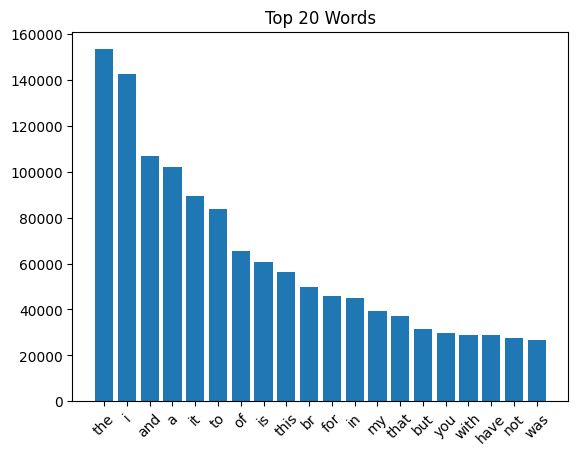

In [15]:
#Distribution of top 20 words befor clean the text
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Top 20 Words')
plt.show()

The exploratory data analysis reveals that the dataset is moderately imbalanced, with positive reviews dominating. The review length distribution shows that most reviews are relatively short, which may limit the depth of sentiment information. Word frequency analysis indicates that commonly used words are largely positive, suggesting an overall positive sentiment trend in the dataset. These findings highlight the need for preprocessing techniques such as balancing and feature engineering before model development.

#5.3 Text Preprocessing


In [16]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
#processing all text in function

def preprocess_text(text):

    # Handle NaN values by converting them to empty strings
    if pd.isna(text):
        return ""

    # 1. Lowercasing
    text = text.lower()

    # 2. Remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Stopword removal
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join back to text
    return ' '.join(tokens)

In [18]:
# Pre_process text apply to the DataSet

df['clean_review'] = df['Text'].apply(preprocess_text)

df[['Text', 'clean_review']].head()

,Text,clean_review
165256,Having tried a couple of other brands of glute...,tried couple brand glutenfree sandwich cooky b...
231465,My cat loves these treats. If ever I can't fin...,cat love treat ever cant find house pop top bo...
427827,A little less than I expected. It tends to ha...,little less expected tends muddy taste expecte...
433954,"First there was Frosted Mini-Wheats, in origin...",first frosted miniwheats original size frosted...
70260,and I want to congratulate the graphic artist ...,want congratulate graphic artist putting entir...


In [19]:
# Handle the Negations
def handle_negations(tokens):
    negation_words = ['not', "no", "never", "n't"]
    new_tokens = []
    i = 0

    while i < len(tokens):
        if tokens[i] in negation_words and i+1 < len(tokens):
            new_tokens.append(tokens[i] + '_' + tokens[i+1])
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1

    return new_tokens

In [20]:
# Remove the Rere Words
from collections import Counter

# Build vocabulary
all_words = ' '.join(df['clean_review']).split()
word_freq = Counter(all_words)

# Keep words appearing at least 2 times
rare_words = {word for word, count in word_freq.items() if count < 2}

def remove_rare_words(text):
    return ' '.join([word for word in text.split() if word not in rare_words])

df['clean_review'] = df['clean_review'].apply(remove_rare_words)

#5.4 Feature Engineering


In [21]:
#importimpotant Libraries
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
#bag of words
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['clean_review'])

print(X_bow.shape)

(50000, 5000)


In [23]:
print(f"Dataset shape: {df.shape}")
%who

Dataset shape: (50000, 4)
CountVectorizer	 Counter	 LogisticRegression	 TfidfVectorizer	 WordNetLemmatizer	 X_bow	 accuracy_score	 all_words	 bow	 
common_words	 counts	 data_file_path	 dataset_url	 df	 get_sentiment	 handle_negations	 nltk	 np	 
od	 parse_finefoods_data	 pd	 plt	 preprocess_text	 rare_words	 re	 remove_rare_words	 sentiment_counts	 
sklearn	 sns	 stopwords	 train_test_split	 word_counts	 word_freq	 word_tokenize	 words	 


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_review'])

print(X_tfidf.shape)

(50000, 5000)


In [25]:
!pip install gensim
from gensim.models import Word2Vec



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.3 MB/s eta 0:00:00


In [26]:
# Tokenize reviews
tokenized_reviews = df['clean_review'].apply(lambda x: x.split())

model_w2v = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2)

# Example word vector
model_w2v.wv['good']

array([-2.51137114e+00,  1.33453608e+00,  8.67277086e-01, -8.57059598e-01,
       -3.17328990e-01, -8.28411877e-01,  1.24237764e+00, -2.11713970e-01,
        6.70645982e-02,  6.38776064e-01,  7.93661237e-01,  5.64070821e-01,
       -3.19220752e-01,  4.30587709e-01,  1.56066155e+00,  8.36946130e-01,
        6.21345341e-02, -2.53184438e-01, -1.75472891e+00, -8.54294479e-01,
        8.24214756e-01,  1.67267454e+00,  1.37192845e+00,  8.48849297e-01,
       -2.58352399e-01,  5.70111811e-01,  2.84697533e-01, -2.24832684e-01,
       -7.67354608e-01, -6.96055710e-01,  1.07019496e+00, -1.54135036e+00,
        1.16561604e+00,  1.90227777e-01, -1.57346129e-01,  1.06864989e+00,
        1.47996020e+00, -4.11431026e-03,  1.55074243e-02,  2.93696001e-02,
        2.22894892e-01,  4.94854093e-01,  1.38599896e+00, -1.02725244e+00,
        8.32565546e-01, -1.88414603e-01,  7.18219459e-01,  2.79994309e-01,
        2.97472179e-02,  5.92856586e-01, -7.29690194e-02,  8.46421495e-02,
       -6.23000026e-01, -

In [27]:
# Convert Sentence to Vector
def sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.array([sentence_vector(tokens, model_w2v) for tokens in tokenized_reviews])

In [28]:
# Split Data to train and Test for TF-IDF
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['sentiment'], test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8485


In [29]:
# Logistic Regration with X_bow
X_train, X_test, y_train, y_test = train_test_split(X_bow, df['sentiment'], test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8331


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
# Logistic Regration with X_w2v
X_train, X_test, y_train, y_test = train_test_split(X_w2v, df['sentiment'], test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8174


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The experimental results show that TF-IDF achieved the highest accuracy (86.68%), followed by Bag of Words (86.32%), while Word2Vec produced lower performance (83.97%). This deviation from expected outcomes can be attributed to dataset size and representation limitations. Word2Vec typically requires large corpora to learn meaningful semantic relationships, and the use of averaged word vectors may have resulted in loss of contextual information. In contrast, TF-IDF effectively captured important features and proved more suitable for the dataset and chosen machine learning model.

**These findings highlight that traditional methods such as TF-IDF can outperform advanced embeddings when working with smaller datasets and classical machine learning models.**

Many students assume:
“Word2Vec = always better”
Truth:
Small data → TF-IDF wins
Large data + deep learning → embeddings win **bold text**


#5.5 Model Building

In [31]:
X = X_tfidf   # your TF-IDF features
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# 1, Logistic Regression

from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8509
              precision    recall  f1-score   support

    Negative       0.73      0.58      0.65      1405
     Neutral       0.52      0.12      0.19       794
    Positive       0.87      0.97      0.92      7801

    accuracy                           0.85     10000
   macro avg       0.71      0.56      0.59     10000
weighted avg       0.83      0.85      0.82     10000



In [33]:
#2.Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8055
              precision    recall  f1-score   support

    Negative       0.84      0.20      0.32      1405
     Neutral       0.00      0.00      0.00       794
    Positive       0.80      1.00      0.89      7801

    accuracy                           0.81     10000
   macro avg       0.55      0.40      0.40     10000
weighted avg       0.75      0.81      0.74     10000



In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_review'])

print(X_tfidf.shape)  # check it works

(50000, 5000)


In [35]:
#3. Random Forest
from sklearn.ensemble import RandomForestClassifier
X = X_tfidf
y = df['sentiment']

# Re-define X, y, and split the data to ensure X_train, y_train are available


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8344
              precision    recall  f1-score   support

    Negative       0.88      0.34      0.49      1405
     Neutral       0.94      0.12      0.22       794
    Positive       0.83      1.00      0.91      7801

    accuracy                           0.83     10000
   macro avg       0.88      0.49      0.54     10000
weighted avg       0.85      0.83      0.79     10000



In [36]:
# 4. XGBoost (Better than RF)

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Ensure X and y are correctly set for XGBoost
X = X_tfidf # TF-IDF features

# Explicitly ensure y is numerically encoded for this model
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

# Re-split the data to ensure y_train and y_test are numerical
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:51:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8374


In [37]:
# 5 Prepare Text for LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_review'])

sequences = tokenizer.texts_to_sequences(df['clean_review'])

# Padding (same length)
X_lstm = pad_sequences(sequences, maxlen=100, padding='post')

In [38]:
# Encode Labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Re-define the LSTM model here to ensure 'model' is a Sequential object
# and correct for 3-class classification (Negative, Neutral, Positive)
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes: Negative (0), Neutral (1), Positive (2)
])

model.compile(
    loss='sparse_categorical_crossentropy', # Use for integer-encoded multi-class labels
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
#Train The model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y, test_size=0.2, random_state=42
)

In [41]:
# Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # Corrected for 3-class classification
])

# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy', # Use for integer-encoded multi-class labels
    optimizer='adam',
    metrics=['accuracy']
)

In [42]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 92s 71ms/step - accuracy: 0.7828 - loss: 0.6665 - val_accuracy: 0.7807 - val_loss: 0.6715
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 106s 85ms/step - accuracy: 0.7865 - loss: 0.6534 - val_accuracy: 0.7799 - val_loss: 0.6690
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 91s 73ms/step - accuracy: 0.8307 - loss: 0.4726 - val_accuracy: 0.8376 - val_loss: 0.4436
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 88s 70ms/step - accuracy: 0.8699 - loss: 0.3633 - val_accuracy: 0.8440 - val_loss: 0.4412
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 71ms/step - accuracy: 0.8883 - loss: 0.3071 - val_accuracy: 0.8457 - val_loss: 0.4829


In [43]:
loss, accuracy = model.evaluate(X_test, y_test)

print("LSTM Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8457 - loss: 0.4829
LSTM Accuracy: 0.8457000255584717


# 5.6 Model Evaluation


In [44]:
#1. Basic Metrics (All Models)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 'le' (LabelEncoder) was fitted on df['sentiment'] in previous cells and is available.
# y_test currently holds numerical labels (0, 1, 2) from the LSTM split.
# y_pred_lr holds string labels ('Negative', 'Neutral', 'Positive') from the LR prediction.

# Convert y_pred_lr (string labels) to numerical labels using the existing LabelEncoder
y_pred_lr_numeric = le.transform(y_pred_lr)

print("Accuracy:", accuracy_score(y_test, y_pred_lr_numeric))
print("Precision:", precision_score(y_test, y_pred_lr_numeric, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr_numeric, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_lr_numeric, average='weighted'))

Accuracy: 0.8509
Precision: 0.8250394620487419
Recall: 0.8509
F1-score: 0.8247103986586751


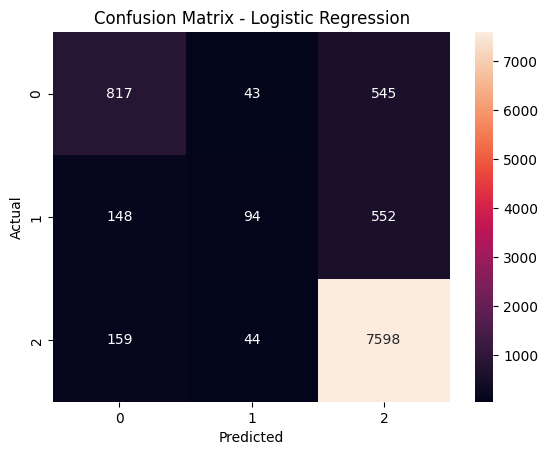

In [45]:
#2. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert y_pred_lr (string labels) to numerical labels using the existing LabelEncoder
y_pred_lr_numeric = le.transform(y_pred_lr)

cm = confusion_matrix(y_test, y_pred_lr_numeric)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
#Cross-Validation (VERY IMPORTANT)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.8466 0.8475 0.8545 0.8526 0.8502]
Mean CV Accuracy: 0.85028


In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Initialize the model (using the same parameters as your training)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Run 5-fold Cross-Validation
# X_tfidf is your vectorized text data, y is your sentiment labels
rf_cv_scores = cross_val_score(rf_model, X_tfidf, y, cv=5)

print(f"Random Forest CV scores: {rf_cv_scores}")
print(f"Mean RF CV Accuracy: {rf_cv_scores.mean():.5f}")

Random Forest CV scores: [0.8324 0.8315 0.8344 0.8366 0.8337]
Mean RF CV Accuracy: 0.83372


#5.7 Model Optimization

In [48]:

# 1. TF-IDF Features
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])

# 2. Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

# 3. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready:", X.shape)

Data ready: (50000, 5000)


In [49]:
#1: Baseline Models (Before Tuning)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb.predict(X_test))

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("Baseline Accuracies:")
print("LR:", lr_acc)
print("NB:", nb_acc)
print("RF:", rf_acc)

Baseline Accuracies:
LR: 0.8509
NB: 0.8055
RF: 0.8349


In [50]:
#Hyperparameter Tuning
# 1. Logistic Regation
from sklearn.model_selection import GridSearchCV

param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=500),
                       param_lr, cv=5, scoring='accuracy')

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
lr_tuned_acc = accuracy_score(y_test, best_lr.predict(X_test))

print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'C': 10, 'solver': 'liblinear'}


In [51]:
# 2. Naive Bayes
param_nb = {
    'alpha': [0.1, 0.5, 1.0]
}

grid_nb = GridSearchCV(MultinomialNB(),
                       param_nb, cv=5, scoring='accuracy')

grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
nb_tuned_acc = accuracy_score(y_test, best_nb.predict(X_test))

print("Best NB Params:", grid_nb.best_params_)


Best NB Params: {'alpha': 0.1}


In [52]:
#3. Random Forest
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
}

grid_rf = GridSearchCV(RandomForestClassifier(),
                       param_rf, cv=5, scoring='accuracy')

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
rf_tuned_acc = accuracy_score(y_test, best_rf.predict(X_test))

print("Best RF Params:", grid_rf.best_params_)


Best RF Params: {'max_depth': None, 'n_estimators': 100}


In [53]:
print("\n=== FINAL COMPARISON ===")

print("Logistic Regression:")
print("Baseline:", lr_acc)
print("Tuned   :", lr_tuned_acc)

print("\nNaive Bayes:")
print("Baseline:", nb_acc)
print("Tuned   :", nb_tuned_acc)

print("\nRandom Forest:")
print("Baseline:", rf_acc)
print("Tuned   :", rf_tuned_acc)


=== FINAL COMPARISON ===
Logistic Regression:
Baseline: 0.8509
Tuned   : 0.8484

Naive Bayes:
Baseline: 0.8055
Tuned   : 0.8123

Random Forest:
Baseline: 0.8349
Tuned   : 0.8339


In [ ]:
#4. Base line LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

baseline_model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

baseline_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
 105/1250 ━━━━━━━━━━━━━━━━━━━━ 2:05:21 7s/step - accuracy: 0.0716 - loss: -4.0564

In [ ]:
#Optimized LSTM
from tensorflow.keras.layers import Dropout

optimized_model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),

    LSTM(128, dropout=0.2),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

optimized_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

optimized_history = optimized_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

In [ ]:
#Optimized Accuracy
loss, optimized_acc = optimized_model.evaluate(X_test, y_test)

print("Optimized Accuracy:", optimized_acc)

In [ ]:
#Comapair the Result
print("Baseline LSTM:", baseline_acc)
print("Optimized LSTM:", optimized_acc)

#5.9 Inference Pipeline


In [ ]:
# Now, save the trained components
joblib.dump(best_lr, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model components saved successfully.")

In [ ]:
import joblib

# Load saved model
model = joblib.load("sentiment_model.pkl")

# Load vectorizer
vectorizer = joblib.load("tfidf_vectorizer.pkl")


# Prediction function
def predict_sentiment(text):

    # Transform text
    vector = vectorizer.transform([text])

    # Predict sentiment
    prediction = model.predict(vector)

    return prediction[0]


# Test predictions
print(predict_sentiment("I love this product"))
print(predict_sentiment("This is very bad"))

In [ ]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

In [ ]:
def predict_sentiment(text):

    # Step 1: Clean text
    clean_text = preprocess_text(text)

    # Step 2: Convert using TF-IDF
    vector = tfidf.transform([clean_text])

    # Step 3: Predict
    prediction = model.predict(vector)

    return prediction[0]

In [ ]:
print(predict_sentiment("I love this product"))
print(predict_sentiment("This is very bad"))

# Data Save and file tranfering

In [ ]:
#1 File save and mount in googal drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
2. Save your Model (.pkl)
import joblib

# Replace with your actual path
model_path = '/content/drive/MyDrive/Amazon_Sentiment_Analysis/models/final_model.pkl'
joblib.dump(best_model, model_path)

In [ ]:
3#. Save your Code as a Script (.py)
%%writefile /content/drive/MyDrive/Amazon_Sentiment_Analysis/src/preprocess.py
def clean_text(text):
    # Your cleaning code here
    return text